# Analyse bivariée — variables du modèle

Cette analyse porte sur les **33 variables réellement candidates**, produites par
`src/features.py`, et non sur les colonnes brutes — celles-ci ont été explorées
dans `01_EDA.ipynb`.

**Ce que ce notebook cherche :**

1. **Valider le feature engineering.** `t_High_Intensity` doit corréler
   positivement avec la consommation, `HasSteam` doit séparer les profils
   d'émissions, `logGFAtotal` doit dominer. Un comportement inattendu signale un
   bug dans `features.py`, qu'il vaut mieux trouver avant d'entraîner sept modèles.
2. **Trancher `ParkingRatio` contre `t_Parking`** — le dernier candidat resté
   ouvert (écart E13).
3. **Repérer la colinéarité**, pour interpréter la régression linéaire du
   benchmark. Les modèles à arbres y sont insensibles.
4. **Produire les figures** des sections 2 et 3 du rapport.

**Ce que ce notebook ne fait pas :** de la sélection de variables. Avec 33
features pour 1655 lignes, les modèles à arbres trient seuls et le benchmark
arbitre. Aucun élagage manuel ici.

In [14]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# Resolve the project root whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import features as F  # noqa: E402

pd.set_option("display.max_columns", 60)
sns.set_theme(style="ticks")

## Construction du jeu d'analyse

On rejoue exactement le chemin d'entraînement : `from_benchmark` pour passer aux
booléens d'énergie et retirer les colonnes de consommation, puis `build_features`.
Les cibles sont passées en `log1p`, comme elles le seront à l'entraînement.

In [15]:
raw = pd.read_csv(ROOT / "data" / "dfclean.csv")
desc = F.from_benchmark(raw)

X = F.build_features(desc)
y = pd.DataFrame({
    "Energy_Log": np.log1p(desc["SiteEnergyUse(kBtu)"]),
    "LogEmissions": np.log1p(desc["TotalGHGEmissions"]),
})

print(f"{X.shape[0]} bâtiments, {X.shape[1]} variables")
X.describe().T

Dropped 1 building(s) with no usage breakdown: [496]
1655 bâtiments, 33 variables


,count,mean,std,min,25%,50%,75%,max
YearBuilt,1655.0,1961.879758,32.728622,1900.000000,1930.000000,1965.000000,1989.000000,2015.000000
NumberofBuildings,1655.0,1.200604,2.933709,1.000000,1.000000,1.000000,1.000000,111.000000
NumberofFloors,1655.0,4.151057,6.577059,1.000000,1.000000,2.000000,4.000000,99.000000
logGFAtotal,1655.0,11.045530,0.956592,9.331318,10.288682,10.804726,11.566940,16.047690
ParkingRatio,1655.0,0.061360,0.140298,0.000000,0.000000,0.000000,0.000000,0.895023
NbUsage,1655.0,1.887613,1.187678,1.000000,1.000000,2.000000,2.000000,11.000000
HasElectricity,1655.0,0.996979,0.054898,0.000000,1.000000,1.000000,1.000000,1.000000
HasGas,1655.0,0.716616,0.450777,0.000000,0.000000,1.000000,1.000000,1.000000
HasSteam,1655.0,0.068882,0.253330,0.000000,0.000000,0.000000,0.000000,1.000000
nb_BALLARD,1655.0,0.041692,0.199944,0.000000,0.000000,0.000000,0.000000,1.000000


## 1. Corrélation avec les cibles

Corrélation de Pearson de chaque variable avec les deux cibles en log. C'est un
premier classement, pas une vérité : une corrélation linéaire faible n'interdit
pas à un arbre d'exploiter la variable.

In [16]:
corr_targets = pd.DataFrame({
    "Energy_Log": X.corrwith(y["Energy_Log"]),
    "LogEmissions": X.corrwith(y["LogEmissions"]),
}).sort_values("Energy_Log", key=abs, ascending=False)

corr_targets.round(3)

,Energy_Log,LogEmissions
logGFAtotal,0.769,0.620
NumberofFloors,0.417,0.306
t_Storage_Dry,-0.357,-0.310
t_Parking,0.289,0.160
ParkingRatio,0.271,0.144
YearBuilt,0.260,0.160
HasSteam,0.243,0.309
NbUsage,0.235,0.167
nb_DOWNTOWN,0.221,0.143
nb_GREATER_DUWAMISH,-0.200,-0.184


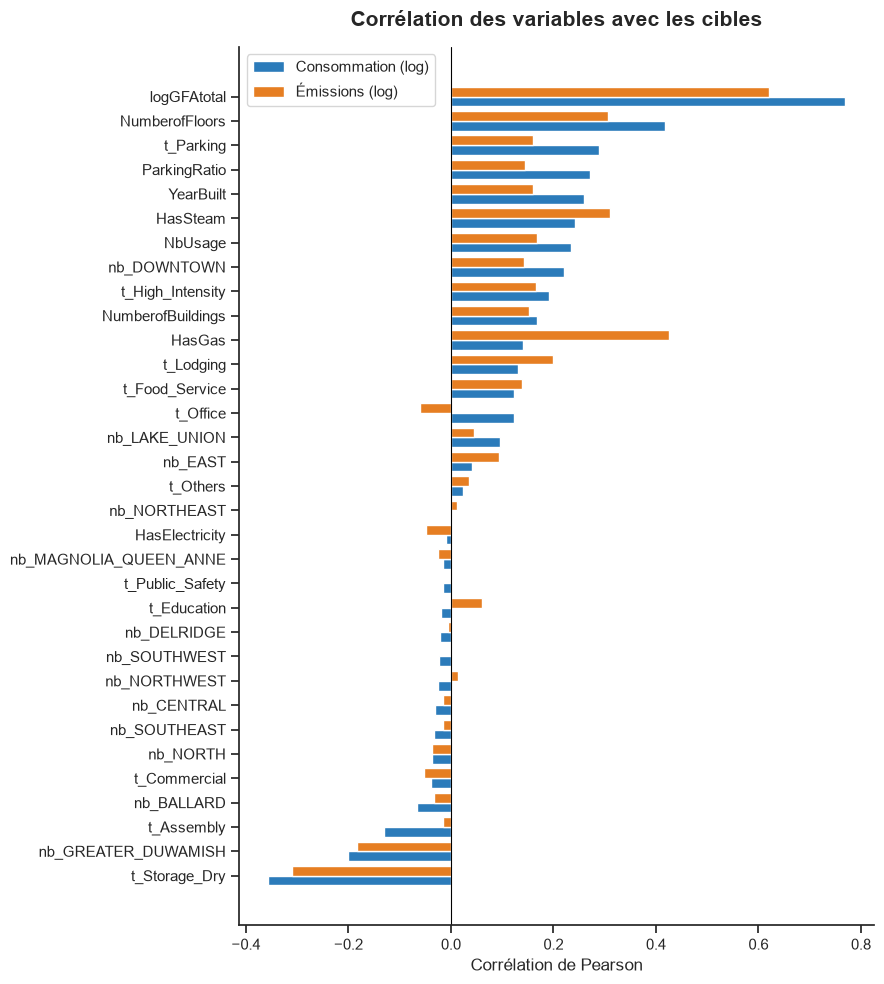

In [17]:
fig, ax = plt.subplots(figsize=(9, 10))
plot_df = corr_targets.sort_values("Energy_Log")
ypos = np.arange(len(plot_df))

ax.barh(ypos - 0.2, plot_df["Energy_Log"], height=0.4, label="Consommation (log)", color="#2b7bba")
ax.barh(ypos + 0.2, plot_df["LogEmissions"], height=0.4, label="Émissions (log)", color="#e67e22")
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df.index)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Corrélation de Pearson")
ax.set_title("Corrélation des variables avec les cibles", fontsize=15, pad=15, fontweight="bold")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 2. Colinéarité entre variables

Seules les paires réellement corrélées nous intéressent — la matrice complète 33 × 33
est illisible et la plupart des couples sont à zéro par construction (les colonnes
one-hot s'excluent mutuellement).

In [18]:
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

pairs = (
    corr.where(~mask)
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
pairs["abs"] = pairs["correlation"].abs()
strong = pairs.sort_values("abs", ascending=False).head(15).drop(columns="abs")
strong.round(3).reset_index(drop=True)

,variable_1,variable_2,correlation
0,t_Parking,ParkingRatio,0.643
1,logGFAtotal,NumberofFloors,0.539
2,t_Storage_Dry,nb_GREATER_DUWAMISH,0.495
3,nb_DOWNTOWN,NumberofFloors,0.431
4,t_Parking,logGFAtotal,0.390
5,ParkingRatio,logGFAtotal,0.357
6,t_Parking,NbUsage,0.354
7,ParkingRatio,YearBuilt,0.340
8,t_Parking,YearBuilt,0.324
9,nb_DOWNTOWN,HasSteam,0.298


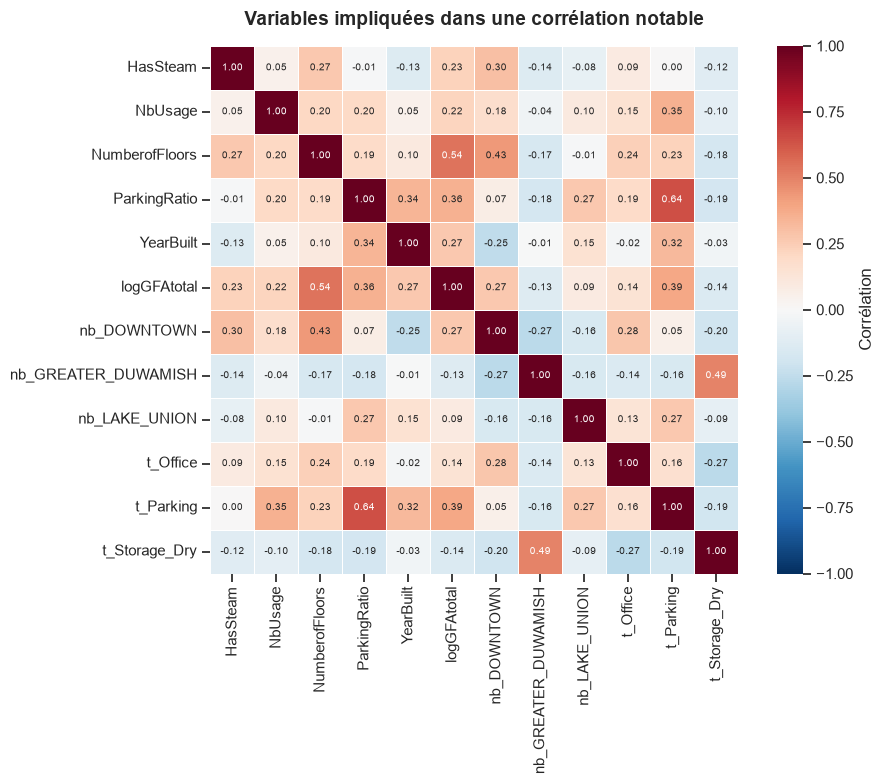

In [19]:
# Restrict the heatmap to the variables involved in at least one notable pair
involved = sorted(set(strong["variable_1"]) | set(strong["variable_2"]))

fig, ax = plt.subplots(figsize=(10, 8))
sub = X[involved].corr()
sns.heatmap(
    sub, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    square=True, linewidths=0.5, cbar_kws={"label": "Corrélation"}, ax=ax,
)
ax.set_title("Variables impliquées dans une corrélation notable", fontsize=14, pad=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. `ParkingRatio` contre `t_Parking` — écart E13, **tranché**

`t_Parking` est la part du parking dans les **usages déclarés** ; `ParkingRatio`
était la surface de parking rapportée à la **surface totale**, depuis une colonne
source différente. P3 avait écarté la seconde comme redondante ; on l'avait
réintroduite pour vérifier.

**Conclusion : P3 avait raison, `ParkingRatio` est retirée.** Elle n'apporte aucun
signal mesurable au-delà de `t_Parking`, et elle coûterait un champ de saisie
supplémentaire dans l'interface. Elle est recalculée à la volée ci-dessous, à
partir de la description, pour garder la trace de la décision.

In [20]:
# Recomputed here only: the variable no longer belongs to the feature set
parking_ratio = desc["PropertyGFAParking"] / desc["PropertyGFATotal"]

print("corrélation entre les deux :", round(parking_ratio.corr(X["t_Parking"]), 3))
print()
print(pd.DataFrame({
    "corr. consommation": [parking_ratio.corr(y["Energy_Log"]), X["t_Parking"].corr(y["Energy_Log"])],
    "corr. émissions": [parking_ratio.corr(y["LogEmissions"]), X["t_Parking"].corr(y["LogEmissions"])],
}, index=["ParkingRatio (retirée)", "t_Parking"]).round(3))

corrélation entre les deux : 0.643

                        corr. consommation  corr. émissions
ParkingRatio (retirée)               0.271            0.144
t_Parking                            0.289            0.160


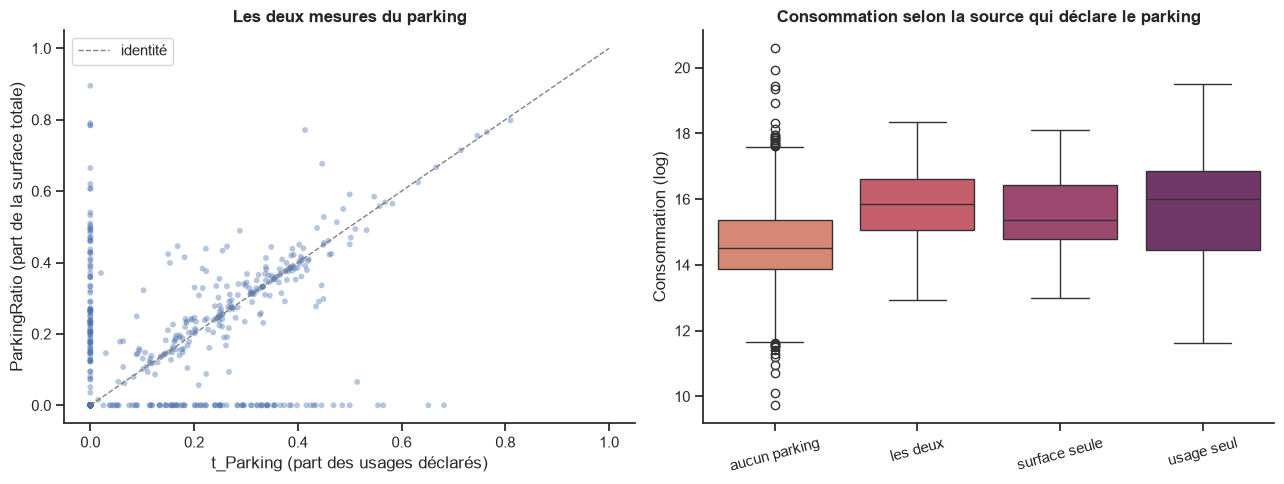

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X["t_Parking"], parking_ratio, alpha=0.4, s=18, edgecolor="none")
axes[0].plot([0, 1], [0, 1], "--", color="grey", linewidth=1, label="identité")
axes[0].set_xlabel("t_Parking (part des usages déclarés)")
axes[0].set_ylabel("ParkingRatio (part de la surface totale)")
axes[0].set_title("Les deux mesures du parking", fontweight="bold")
axes[0].legend()

category = np.select(
    [(parking_ratio > 0) & (X["t_Parking"] > 0), parking_ratio > 0, X["t_Parking"] > 0],
    ["les deux", "surface seule", "usage seul"], default="aucun parking",
)
sns.boxplot(x=category, y=y["Energy_Log"], ax=axes[1], hue=category, legend=False, palette="flare")
axes[1].set_xlabel("")
axes[1].set_ylabel("Consommation (log)")
axes[1].set_title("Consommation selon la source qui déclare le parking", fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)

sns.despine()
plt.tight_layout()
plt.show()

## 4. Validation du feature engineering

Trois contrôles de cohérence. Si l'un échoue, le bug est dans `features.py`, pas
dans les données.

### 4.1 — `logGFAtotal` doit dominer

La surface est le premier déterminant de la consommation d'un bâtiment. Si cette
variable n'arrive pas en tête du classement de la section 1, quelque chose ne va pas.

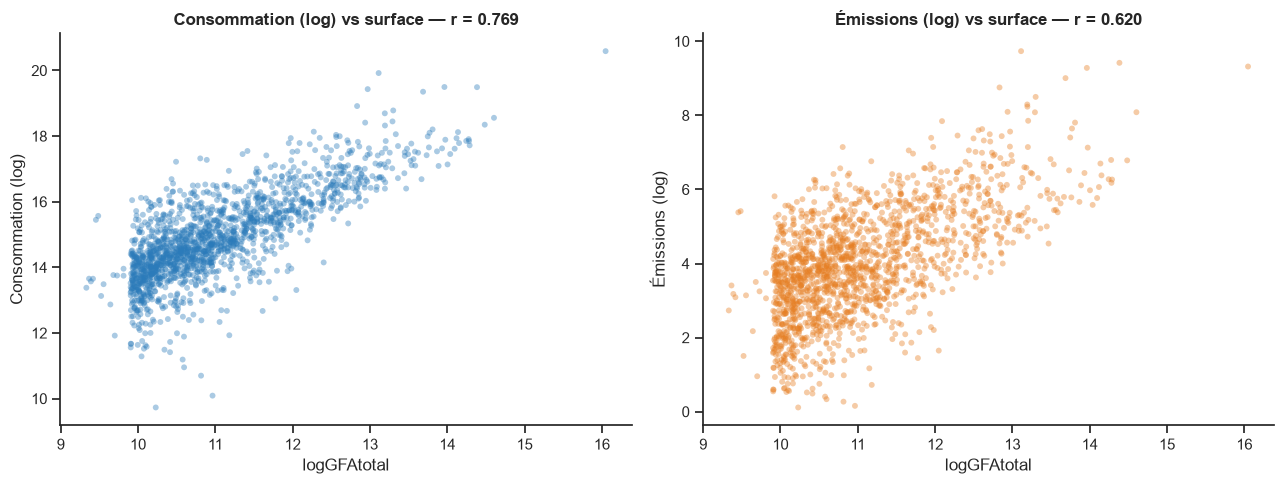

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, target, label, color in [
    (axes[0], "Energy_Log", "Consommation (log)", "#2b7bba"),
    (axes[1], "LogEmissions", "Émissions (log)", "#e67e22"),
]:
    ax.scatter(X["logGFAtotal"], y[target], alpha=0.4, s=18, edgecolor="none", color=color)
    ax.set_xlabel("logGFAtotal")
    ax.set_ylabel(label)
    r = X["logGFAtotal"].corr(y[target])
    ax.set_title(f"{label} vs surface — r = {r:.3f}", fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

### 4.2 — Les groupes d'usage doivent se comporter selon leur intensité

`t_High_Intensity` (data centers, labos, hôpitaux) doit tirer la consommation vers
le haut, `t_Storage_Dry` (entrepôts secs) vers le bas. On regarde l'intensité
énergétique — la consommation par pied carré — pour neutraliser l'effet de taille.

In [23]:
intensity = np.log1p(desc["SiteEnergyUse(kBtu)"] / desc["PropertyGFATotal"])

rows = []
for group in F.USAGE_GROUPS:
    dominant = X[group] > 0.5  # buildings mostly dedicated to this use
    if dominant.sum() >= 10:
        rows.append({
            "groupe": group,
            "bâtiments": int(dominant.sum()),
            "intensité médiane (log kBtu/sqft)": float(intensity[dominant].median()),
        })

pd.DataFrame(rows).sort_values("intensité médiane (log kBtu/sqft)", ascending=False).reset_index(drop=True)

,groupe,bâtiments,intensité médiane (log kBtu/sqft)
0,t_Food_Service,53,5.269229
1,t_High_Intensity,51,5.112770
2,t_Others,94,4.411472
3,t_Lodging,127,4.264646
4,t_Commercial,117,4.024568
5,t_Office,518,3.870250
6,t_Assembly,148,3.829544
7,t_Education,165,3.709349
8,t_Parking,18,3.682702
9,t_Storage_Dry,272,3.253578


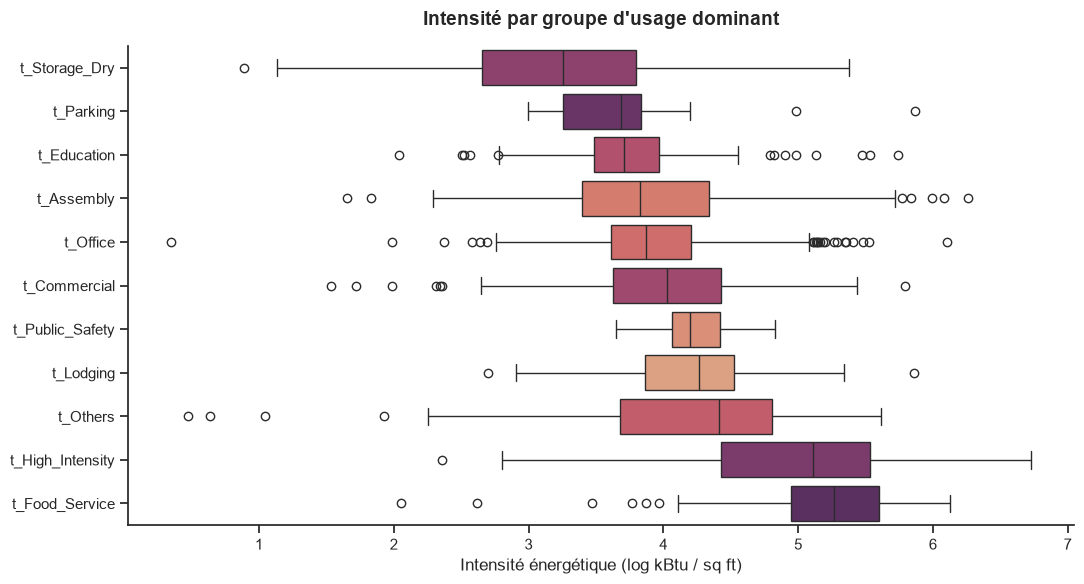

In [24]:
dominant_group = X[list(F.USAGE_GROUPS)].idxmax(axis=1)
is_dominant = X[list(F.USAGE_GROUPS)].max(axis=1) > 0.5
plot_df = pd.DataFrame({"groupe": dominant_group[is_dominant], "intensite": intensity[is_dominant]})
order = plot_df.groupby("groupe")["intensite"].median().sort_values().index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=plot_df, y="groupe", x="intensite", order=order, hue="groupe", legend=False, palette="flare", ax=ax)
ax.set_xlabel("Intensité énergétique (log kBtu / sq ft)")
ax.set_ylabel("")
ax.set_title("Intensité par groupe d'usage dominant", fontsize=14, pad=15, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

### 4.3 — Les sources d'énergie doivent séparer les profils

C'est le contrôle le plus important : ces trois booléens **remplacent** les ratios
de P3 (écart E08). S'ils ne discriminent rien, le remplacement a coûté toute
l'information et il faudra le dire dans le rapport.

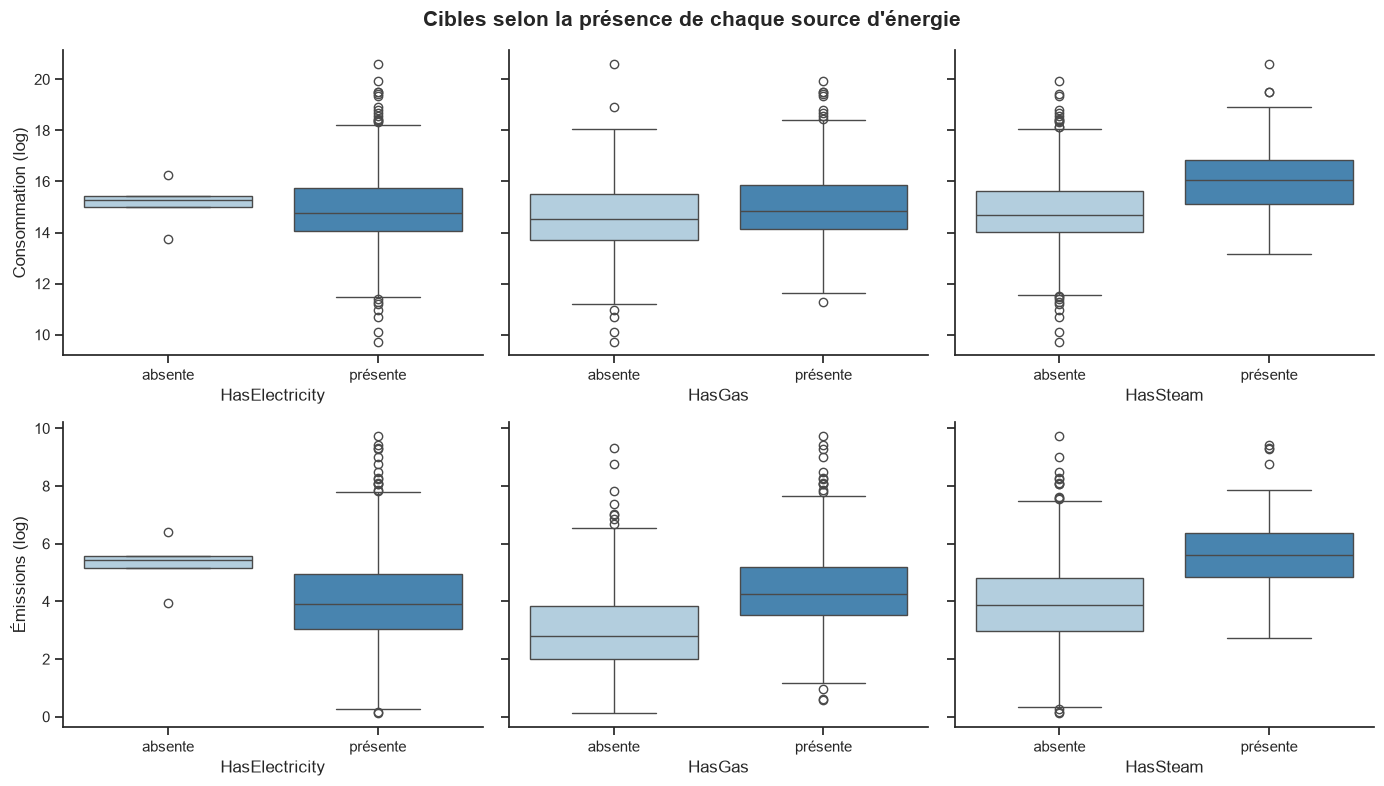

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey="row")

for col, source in enumerate(["HasElectricity", "HasGas", "HasSteam"]):
    for row, (target, label) in enumerate([("Energy_Log", "Consommation (log)"), ("LogEmissions", "Émissions (log)")]):
        ax = axes[row, col]
        sns.boxplot(x=X[source], y=y[target], ax=ax, hue=X[source], legend=False, palette="Blues")
        ax.set_xlabel(source)
        ax.set_ylabel(label if col == 0 else "")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["absente", "présente"])

fig.suptitle("Cibles selon la présence de chaque source d'énergie", fontsize=15, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

In [26]:
# Effect size: median gap between the two groups, in original units
summary = []
for source in ["HasElectricity", "HasGas", "HasSteam"]:
    present = desc.loc[X[source] == 1, "SiteEnergyUse(kBtu)"]
    absent = desc.loc[X[source] == 0, "SiteEnergyUse(kBtu)"]
    summary.append({
        "source": source,
        "n présente": len(present),
        "n absente": len(absent),
        "médiane présente (kBtu)": round(present.median()),
        "médiane absente (kBtu)": round(absent.median()) if len(absent) else None,
        "corr. consommation": round(X[source].corr(y["Energy_Log"]), 3),
    })

pd.DataFrame(summary)

,source,n présente,n absente,médiane présente (kBtu),médiane absente (kBtu),corr. consommation
0,HasElectricity,1650,5,2572873,4318917,-0.009
1,HasGas,1186,469,2742048,2037721,0.141
2,HasSteam,114,1541,9281410,2399354,0.243


## 5. Analyses numérique × catégorie

Les sections 4.2 et 4.3 en relèvent déjà — intensité par groupe d'usage dominant,
cibles par source d'énergie. Deux compléments : le quartier, et l'année de
construction, dont la corrélation positive avec la consommation demande une
explication.

### 5.1 — Cibles par quartier

13 quartiers après la normalisation de casse (écart E07). On regarde à la fois la
consommation absolue et l'intensité au pied carré : la première est dominée par la
taille des bâtiments du quartier, la seconde décrit leur nature.

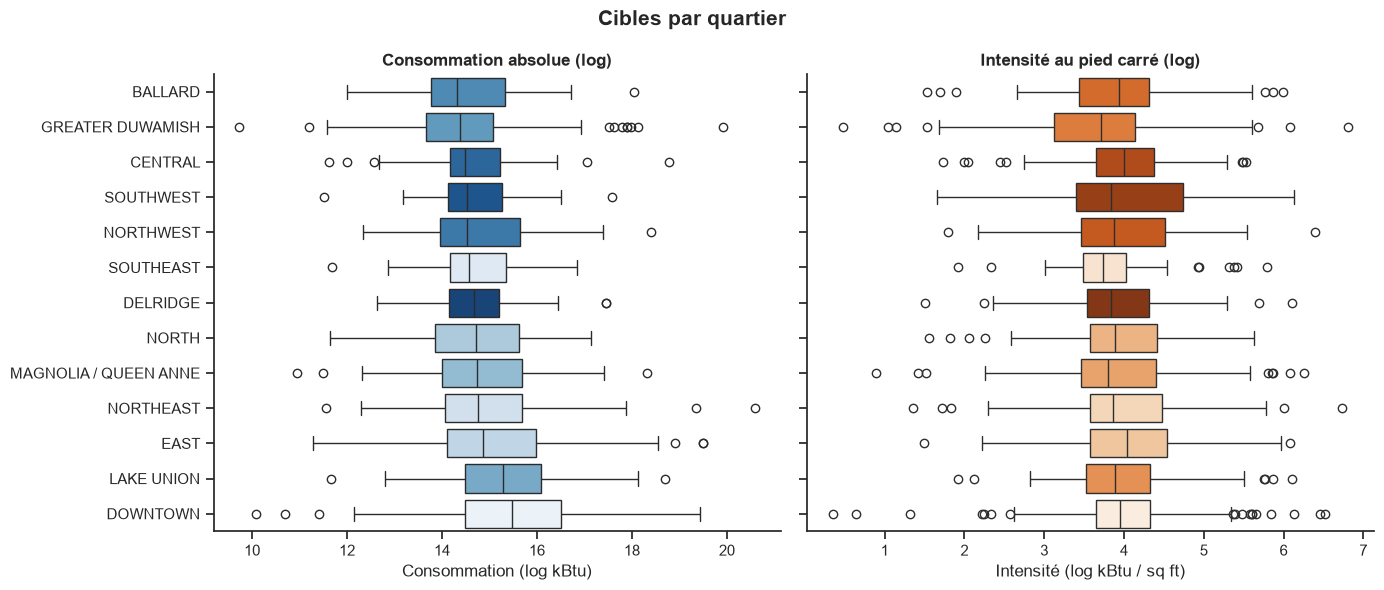

,n,conso_mediane,intensite_mediane
quartier,,,
EAST,120,14.85,4.03
CENTRAL,54,14.49,4.00
DOWNTOWN,358,15.47,3.95
BALLARD,69,14.31,3.93
NORTH,65,14.71,3.89
LAKE UNION,147,15.28,3.89
NORTHWEST,85,14.53,3.88
NORTHEAST,127,14.75,3.87
SOUTHWEST,41,14.53,3.84


In [27]:
plot_df = pd.DataFrame({
    "quartier": desc["Neighborhood"],
    "Energy_Log": y["Energy_Log"],
    "intensite": np.log1p(desc["SiteEnergyUse(kBtu)"] / desc["PropertyGFATotal"]),
})
order = plot_df.groupby("quartier")["Energy_Log"].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.boxplot(data=plot_df, y="quartier", x="Energy_Log", order=order,
            hue="quartier", legend=False, palette="Blues", ax=axes[0])
axes[0].set_title("Consommation absolue (log)", fontweight="bold")
axes[0].set_xlabel("Consommation (log kBtu)")
axes[0].set_ylabel("")

sns.boxplot(data=plot_df, y="quartier", x="intensite", order=order,
            hue="quartier", legend=False, palette="Oranges", ax=axes[1])
axes[1].set_title("Intensité au pied carré (log)", fontweight="bold")
axes[1].set_xlabel("Intensité (log kBtu / sq ft)")
axes[1].set_ylabel("")

fig.suptitle("Cibles par quartier", fontsize=15, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

plot_df.groupby("quartier").agg(
    n=("Energy_Log", "size"),
    conso_mediane=("Energy_Log", "median"),
    intensite_mediane=("intensite", "median"),
).sort_values("intensite_mediane", ascending=False).round(2)

### 5.2 — L'année de construction : effet de taille, pas effet d'efficacité

`YearBuilt` corrèle positivement avec la consommation (r ≈ 0,26), ce qui se lit
naïvement comme « les bâtiments récents consomment plus ». Le découpage par
décennie permet de savoir si c'est une propriété des bâtiments récents ou un
artefact.

La question décisive : la corrélation tient-elle encore sur l'**intensité**
(consommation par pied carré), qui neutralise la taille ?

In [28]:
by_decade = desc.assign(
    decennie=(desc["YearBuilt"] // 10 * 10).astype(int),
    intensite=desc["SiteEnergyUse(kBtu)"] / desc["PropertyGFATotal"],
).groupby("decennie").agg(
    n=("YearBuilt", "size"),
    surface_mediane=("PropertyGFATotal", "median"),
    conso_mediane=("SiteEnergyUse(kBtu)", "median"),
    intensite_mediane=("intensite", "median"),
)
by_decade = by_decade[by_decade["n"] >= 20]

print("Corrélations avec YearBuilt")
intensite = desc["SiteEnergyUse(kBtu)"] / desc["PropertyGFATotal"]
for label, serie in [
    ("surface (log)", np.log1p(desc["PropertyGFATotal"])),
    ("consommation (log)", y["Energy_Log"]),
    ("intensité (log)", np.log1p(intensite)),
]:
    print(f"  {label:22s} {desc['YearBuilt'].corr(serie):+.3f}")

by_decade.round(1)

Corrélations avec YearBuilt
  surface (log)          +0.273
  consommation (log)     +0.260
  intensité (log)        +0.094


,n,surface_mediane,conso_mediane,intensite_mediane
decennie,,,,
1900,124,45227.5,2084867.7,43.9
1910,111,39952.0,1950713.2,42.7
1920,169,41013.0,2466100.0,48.4
1930,54,41262.0,1579848.4,42.3
1940,63,37377.0,1799664.1,44.1
1950,167,38520.0,1758134.6,46.7
1960,226,40678.5,2187941.8,49.3
1970,165,43794.0,2661488.0,47.0
1980,172,57204.0,2805372.8,45.8


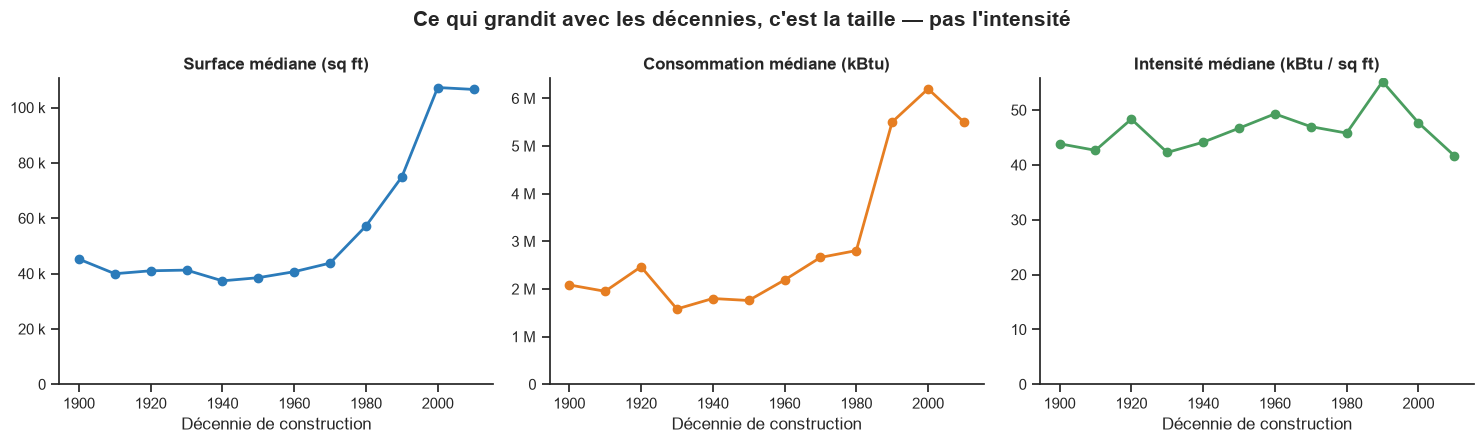

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

panels = [
    ("surface_mediane", "Surface médiane (sq ft)", "#2b7bba"),
    ("conso_mediane", "Consommation médiane (kBtu)", "#e67e22"),
    ("intensite_mediane", "Intensité médiane (kBtu / sq ft)", "#4a9d5f"),
]
for ax, (column, label, color) in zip(axes, panels):
    ax.plot(by_decade.index, by_decade[column], marker="o", color=color, linewidth=2)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Décennie de construction")
    ax.yaxis.set_major_formatter(ticker.EngFormatter())
    ax.set_ylim(bottom=0)

fig.suptitle(
    "Ce qui grandit avec les décennies, c'est la taille — pas l'intensité",
    fontsize=15, fontweight="bold",
)
sns.despine()
plt.tight_layout()
plt.show()

## Conclusions

*Ces conclusions alimentent les sections 2 et 3 du rapport. Toute décision prise
ici est consignée dans `docs/ecarts_vs_P3.md`.*

- **Feature engineering validé** : `logGFAtotal` domine, le mapping par intensité
  énergétique se vérifie dans l'ordre des groupes, `HasSteam` sépare nettement.
  `HasElectricity` est bien la variable nulle attendue (99,7 % de constance).
- **`ParkingRatio` retirée** (E13) : aucun signal au-delà de `t_Parking`, et un
  champ de saisie économisé. P3 avait raison de l'écarter.
- **`YearBuilt`** : à compléter après lecture de la section 5.2.
- **Colinéarités à mentionner pour la régression linéaire** : à compléter.